# 02. Transfer Learning: The Ladder

## 📚 Learning Objectives

By the end of this notebook you will be able to:

- Put four ways of using a pretrained model on **one axis of cost**: use it as-is, freeze it and train a new head, fine-tune part of it, fine-tune all of it.
- Measure, for each rung, three numbers on the same task: **trainable parameters, wall-clock seconds, held-out accuracy**.
- Read the resulting table and say where accuracy stops paying for cost. That is the decision a junior engineer is actually asked to make: not *how* to fine-tune, but *which rung*.

## 🔗 Where this fits

**Builds on:** `01_ai_learning_models.ipynb` in this unit (a held-out set, and why hand-written rules lose to learned ones; rung 1 below *is* a hand-written rule); Course 01 (AIAT 111) Unit 3, lesson 04, where you watched a weight move under gradient descent; Course 01 Unit 4, lesson 05, your first CNN.

**Used later in:** Course 03 (AIAT 113) Unit 1, `enrichment/E5_lora_on_a_matrix.ipynb`, the arithmetic of the 2026 version of rung 3; Course 08 (AIAT 122) Unit 2, lesson 05, which runs the frozen-backbone recipe on MNIST and on two CIFAR-10 classes; Course 10 (AIAT 124), where the same four choices come back with a language model; Course 11 (AIAT 125), where whichever rung you chose has to be served.

This lesson delivers the unit's official bullet *"Transfer Learning (pre-trained models, fine-tuning, domain adaptation)"* and its practical twin *"Applying transfer learning with pre-trained models (VGG, ResNet, BERT)"*.

## The Story: the question is not *how* to fine-tune, it is *whether*

Somebody has already trained a network on ImageNet's 1,000-class photograph collection. You have 1,000 labelled images and a laptop. You have four choices, and they are not four techniques. They are four rungs of one ladder, each more expensive than the last:

| Rung | What moves | What it costs |
|---|---|---|
| 1. Use as-is | nothing | one forward pass |
| 2. Frozen backbone + new head | a few thousand weights | one forward pass, then a tiny model |
| 3. Partial fine-tune | the last block + the head | gradients through part of the network, several times |
| 4. Full fine-tune | every weight | gradients through everything, several times |

Every rung gets **the same 1,000 training images, the same 1,000 held-out test images, the same backbone**. The only thing that changes is how much of the network is allowed to move. For each rung we print three numbers, and the lesson is the table at the end: **where does accuracy stop improving relative to cost?**

The pretrained model is ResNet-18 with ImageNet weights, loaded from `torchvision`. The task is CIFAR-10: 60,000 real 32×32 colour photographs in ten classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck), 50,000 for training and 10,000 for testing, created by Alex Krizhevsky, Vinod Nair and Geoffrey Hinton (Krizhevsky, 2009). We take 100 images per class from its training set and 100 per class from its test set, so that all four rungs finish in about a minute on a laptop CPU.

## 📥 Inputs & 📤 Outputs

**Inputs**

- `keras.datasets.cifar10`: the real CIFAR-10 photographs. Keras caches the archive in your home folder after the first download; after that the notebook needs no network.
- `torchvision.models.resnet18(weights=IMAGENET1K_V1)`: the pretrained backbone, cached the same way after its first download.
- This notebook runs on the **`tfenv` kernel** (it needs `keras` for the data and `torch` for the model). On Colab both are already installed.

**Outputs**

- One printed line per rung: trainable parameters, wall-clock seconds, held-out accuracy.
- One table and one figure putting the four rungs on the same axes.
- Nothing is written to disk.

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights
import keras

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # a Colab GPU if there is one, otherwise the laptop CPU

N_PER_CLASS_TRAIN = 100
N_PER_CLASS_TEST = 100
RES = 96        # ResNet-18 was trained at 224 px. At CIFAR's native 32 px its five stride-2 stages leave a 1×1 map
                # before the last block, so the backbone has almost nothing to look at; 224 px would cost 5× the
                # compute of 96 px for a comparison that does not need it. Every rung pays this handicap equally.
EPOCHS = 3      # rungs 3 and 4 both get exactly this many passes over the training images
LR = 1e-4       # and exactly this learning rate, so the only difference between them is how many weights move

CLASSES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
(x_train_all, y_train_all), (x_test_all, y_test_all) = keras.datasets.cifar10.load_data()
print(f"CIFAR-10 from the keras cache: {len(x_train_all):,} training and {len(x_test_all):,} test photographs, "
      f"{x_train_all.shape[1]}×{x_train_all.shape[2]} px, {len(CLASSES)} classes")

rng = np.random.RandomState(0)      # only chooses WHICH real photographs we use; it invents nothing
def pick(y, n_per_class):
    idx = np.concatenate([rng.choice(np.flatnonzero(y == c), n_per_class, replace=False) for c in range(10)])
    return rng.permutation(idx)
train_idx = pick(y_train_all.ravel(), N_PER_CLASS_TRAIN)
test_idx = pick(y_test_all.ravel(), N_PER_CLASS_TEST)

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
def prepare(x_uint8):
    x = torch.from_numpy(x_uint8).permute(0, 3, 1, 2).float() / 255.0
    x = F.interpolate(x, size=(RES, RES), mode="bilinear", align_corners=False)
    return (x - IMAGENET_MEAN) / IMAGENET_STD     # the backbone expects the colour statistics it was trained with

X_train, y_train = prepare(x_train_all[train_idx]), torch.from_numpy(y_train_all[train_idx].ravel()).long()
X_test, y_test = prepare(x_test_all[test_idx]), torch.from_numpy(y_test_all[test_idx].ravel()).long()
print(f"this notebook uses {len(X_train):,} training and {len(X_test):,} held-out images "
      f"({N_PER_CLASS_TRAIN} + {N_PER_CLASS_TEST} per class), resized to {RES}×{RES} px")
print(f"device: {DEVICE}; torch threads: {torch.get_num_threads()}")

CIFAR-10 from the keras cache: 50,000 training and 10,000 test photographs, 32×32 px, 10 classes
this notebook uses 1,000 training and 1,000 held-out images (100 + 100 per class), resized to 96×96 px
device: cpu; torch threads: 4


In [2]:
def n_params(model, trainable_only=False):
    return sum(p.numel() for p in model.parameters() if p.requires_grad or not trainable_only)

@torch.no_grad()
def predict(model, X, batch=100):
    model.eval()
    return torch.cat([model(X[i:i + batch].to(DEVICE)).argmax(1).cpu() for i in range(0, len(X), batch)])

def accuracy(pred, y):
    return (pred == y).float().mean().item()

def train(model, params, X, y, epochs, lr, batch=50):
    model.eval()    # deliberate, and not the default: a freshly built torchvision model is in train() mode. In eval()
                    # BatchNorm keeps its ImageNet running statistics; gradients still flow through it. In train() it
                    # would re-estimate those statistics from each batch of 50 upscaled 32-px images, so the features
                    # under the head would shift before a single weight had moved far. "Try it" below lets you measure that.
    opt = torch.optim.Adam(params, lr=lr)
    order_rng = torch.Generator().manual_seed(0)
    for _ in range(epochs):
        order = torch.randperm(len(X), generator=order_rng)
        for i in range(0, len(X), batch):
            b = order[i:i + batch]
            loss = F.cross_entropy(model(X[b].to(DEVICE)), y[b].to(DEVICE))
            opt.zero_grad()
            loss.backward()
            opt.step()

LADDER = []     # one row per rung: name, trainable parameters, wall-clock seconds, held-out accuracy
def record(name, trainable, seconds, acc):
    LADDER.append(dict(rung=name, trainable=trainable, seconds=seconds, accuracy=acc))
    print(f"\n>>> {name}\n    trainable parameters: {trainable:>12,}   wall-clock: {seconds:6.1f} s   "
          f"held-out accuracy: {acc:.1%}")

## Rung 1: use the model as-is

ResNet-18 answers one question: *which of the 1,000 ImageNet classes is this?* Our question has ten answers. So before the model can be used at all, somebody has to write down which ImageNet answers count as "ship" and which count as "cat". That table is a **hand-written rule**, exactly the thing lesson 01 showed losing to learned models. It is also what makes rung 1 the cheapest: no gradient, no training labels, one forward pass.

Read the table in the next cell before running it. ImageNet has 118 dog breeds and no deer at all.

In [3]:
t0 = time.perf_counter()
WEIGHTS = ResNet18_Weights.IMAGENET1K_V1
IMAGENET_NAMES = WEIGHTS.meta["categories"]
imagenet_model = resnet18(weights=WEIGHTS).to(DEVICE)
print(f"ResNet-18, {n_params(imagenet_model):,} parameters, {len(IMAGENET_NAMES):,} output classes; torchvision reports "
      f"{WEIGHTS.meta['_metrics']['ImageNet-1K']['acc@1']:.1f}% top-1 accuracy on ImageNet's own validation set")

# ImageNet index -> CIFAR-10 class. Written by hand from the 1,000 category names. Every index not listed here is
# an answer with no CIFAR-10 meaning and counts as wrong.
TO_CIFAR = {}
def link(cifar_class, imagenet_ids):
    for i in imagenet_ids:
        TO_CIFAR[i] = CLASSES.index(cifar_class)
link("airplane",   [404, 895])                                   # airliner, warplane
link("automobile", [436, 468, 511, 609, 627, 656, 661, 751, 817]) # beach wagon ... sports car
link("bird",       list(range(7, 25)) + list(range(80, 101)) + list(range(127, 147)))
link("cat",        [281, 282, 283, 284, 285])                    # the five domestic cats; lynx, cougar etc. left out
link("deer",       [351, 352, 353])                              # ImageNet has NO deer: hartebeest, impala, gazelle are the nearest it has
link("dog",        list(range(151, 269)))                        # 118 breeds
link("frog",       [30, 31, 32])
link("horse",      [339, 603])                                   # sorrel (the only horse), horse cart
link("ship",       [403, 472, 484, 510, 554, 576, 625, 628, 724, 780, 814, 833, 871, 913, 914])
link("truck",      [555, 569, 675, 717, 864, 867])               # fire engine, garbage truck, moving van, pickup, tow truck, trailer truck
print(f"{len(TO_CIFAR)} of the 1,000 ImageNet classes were given a CIFAR-10 meaning; "
      f"{1000 - len(TO_CIFAR)} were not")

imagenet_pred = predict(imagenet_model, X_test)
lookup = torch.full((1000,), -1)
for i, c in TO_CIFAR.items():
    lookup[i] = c
pred_1 = lookup[imagenet_pred]                      # -1 = the model answered something with no CIFAR-10 meaning
sec_1 = time.perf_counter() - t0
record("Rung 1: pretrained model used as-is", 0, sec_1, accuracy(pred_1, y_test))

print(f"\n    {(pred_1 == -1).float().mean():.0%} of the held-out images got an answer outside the ten classes")
print("    per-class accuracy:", "  ".join(f"{c} {accuracy(pred_1[y_test == k], y_test[y_test == k]):.0%}"
                                          for k, c in enumerate(CLASSES)))
deer_answers = [IMAGENET_NAMES[i] for i in imagenet_pred[y_test == CLASSES.index("deer")].tolist()]
top = sorted(set(deer_answers), key=deer_answers.count, reverse=True)[:5]
print("    what it called the 100 real deer, most often:", ", ".join(f"{n} ({deer_answers.count(n)})" for n in top))

ResNet-18, 11,689,512 parameters, 1,000 output classes; torchvision reports 69.8% top-1 accuracy on ImageNet's own validation set
222 of the 1,000 ImageNet classes were given a CIFAR-10 meaning; 778 were not



>>> Rung 1: pretrained model used as-is
    trainable parameters:            0   wall-clock:    3.3 s   held-out accuracy: 28.1%

    55% of the held-out images got an answer outside the ten classes
    per-class accuracy: airplane 14%  automobile 17%  bird 37%  cat 5%  deer 26%  dog 76%  frog 14%  horse 10%  ship 37%  truck 45%
    what it called the 100 real deer, most often: hartebeest (15), dhole (7), gazelle (7), impala (4), worm fence (4)


## Rung 2: freeze the backbone, train a new head

Take the 1,000-way ImageNet head off. What is left turns any image into **512 numbers**: the features the network learned to compute for ImageNet. The backbone is frozen, so those 512 numbers are computed **once** per image and cached. The only model that trains is a 512→10 linear layer on top of them. This is also called a *linear probe*.

In [4]:
t0 = time.perf_counter()
backbone = resnet18(weights=WEIGHTS).to(DEVICE)
backbone.fc = nn.Identity()                 # the ImageNet head comes off; the backbone now maps an image to 512 numbers
for p in backbone.parameters():
    p.requires_grad = False

@torch.no_grad()
def features(X, batch=100):
    backbone.eval()
    return torch.cat([backbone(X[i:i + batch].to(DEVICE)).cpu() for i in range(0, len(X), batch)])

feat_train, feat_test = features(X_train), features(X_test)
print(f"cached features: {tuple(feat_train.shape)} for training, {tuple(feat_test.shape)} held out")

head = nn.Linear(feat_train.shape[1], len(CLASSES)).to(DEVICE)
train(head, head.parameters(), feat_train, y_train, epochs=30, lr=1e-3)   # 30 epochs on cached features costs well under a second
pred_2 = predict(head, feat_test)
sec_2 = time.perf_counter() - t0
record("Rung 2: frozen backbone + new head", n_params(head), sec_2, accuracy(pred_2, y_test))
print("    per-class accuracy:", "  ".join(f"{c} {accuracy(pred_2[y_test == k], y_test[y_test == k]):.0%}"
                                          for k, c in enumerate(CLASSES)))

cached features: (1000, 512) for training, (1000, 512) held out

>>> Rung 2: frozen backbone + new head
    trainable parameters:        5,130   wall-clock:    6.5 s   held-out accuracy: 76.5%
    per-class accuracy: airplane 80%  automobile 90%  bird 59%  cat 64%  deer 75%  dog 73%  frog 82%  horse 83%  ship 74%  truck 85%


## Rung 3: partial fine-tune, the last block and the head

Yosinski, Clune, Bengio and Lipson (2014) measured what everyone now assumes: the first layers of a trained network are general (edges, colours, textures), and "features must eventually transition from general to specific by the last layer". So if only part of the network is allowed to move, the part to choose is the **end**. Here that is the last residual block of ResNet-18, `layer4[1]`, plus the head.

Two decisions in the code deserve a sentence each:

- **Rungs 3 and 4 start from the head that rung 2 just trained**, not from a random one. Kumar, Raghunathan, Jones, Ma and Liang (2022) showed that fine-tuning from a random head lets large, meaningless gradients flow into the backbone and distort the pretrained features; training the head first and then fine-tuning (they call it LP-FT) avoids that. It also makes the ladder honest: each rung *contains* the one below it.
- **Rungs 3 and 4 use the same epochs and the same learning rate** (`EPOCHS`, `LR` in the first cell), so the only difference between them is how many weights move.

In [5]:
def pretrained_with_rung2_head():
    m = resnet18(weights=WEIGHTS)
    m.fc = nn.Linear(m.fc.in_features, len(CLASSES))
    m.fc.load_state_dict(head.state_dict())      # LP-FT: start from the trained head, not a random one
    return m.to(DEVICE)

t0 = time.perf_counter()
partial = pretrained_with_rung2_head()
for p in partial.parameters():
    p.requires_grad = False
for p in list(partial.layer4[1].parameters()) + list(partial.fc.parameters()):
    p.requires_grad = True
train(partial, [p for p in partial.parameters() if p.requires_grad], X_train, y_train, epochs=EPOCHS, lr=LR)
pred_3 = predict(partial, X_test)
sec_3 = time.perf_counter() - t0
record("Rung 3: partial fine-tune (last residual block + head)", n_params(partial, trainable_only=True), sec_3,
       accuracy(pred_3, y_test))
print("    per-class accuracy:", "  ".join(f"{c} {accuracy(pred_3[y_test == k], y_test[y_test == k]):.0%}"
                                          for k, c in enumerate(CLASSES)))


>>> Rung 3: partial fine-tune (last residual block + head)
    trainable parameters:    4,725,770   wall-clock:   15.6 s   held-out accuracy: 76.5%
    per-class accuracy: airplane 70%  automobile 89%  bird 72%  cat 45%  deer 82%  dog 85%  frog 82%  horse 79%  ship 76%  truck 85%


## Rung 4: full fine-tune

Every weight moves. Same starting point as rung 3, same epochs, same learning rate; the backward pass now runs through the whole network instead of one block.

In [6]:
t0 = time.perf_counter()
full = pretrained_with_rung2_head()
for p in full.parameters():
    p.requires_grad = True
train(full, full.parameters(), X_train, y_train, epochs=EPOCHS, lr=LR)
pred_4 = predict(full, X_test)
sec_4 = time.perf_counter() - t0
record("Rung 4: full fine-tune", n_params(full, trainable_only=True), sec_4, accuracy(pred_4, y_test))
print("    per-class accuracy:", "  ".join(f"{c} {accuracy(pred_4[y_test == k], y_test[y_test == k]):.0%}"
                                          for k, c in enumerate(CLASSES)))


>>> Rung 4: full fine-tune
    trainable parameters:   11,181,642   wall-clock:   26.1 s   held-out accuracy: 80.9%
    per-class accuracy: airplane 74%  automobile 92%  bird 65%  cat 65%  deer 75%  dog 79%  frog 93%  horse 90%  ship 81%  truck 95%


## The table

Four rungs, one task, one held-out set. The last column is the price of each step up the ladder: how many extra seconds each additional point of accuracy cost, compared with the rung below.

rung                                                         trainable  % of model  seconds  accuracy          sec per +1 point
-------------------------------------------------------------------------------------------------------------------------------
Rung 1: pretrained model used as-is                                  0       0.0%      3.3     28.1%                (baseline)
Rung 2: frozen backbone + new head                               5,130       0.0%      6.5     76.5%                       0.1
Rung 3: partial fine-tune (last residual block + head)       4,725,770      42.3%     15.6     76.5%     no gain (+0.0 points)
Rung 4: full fine-tune                                      11,181,642     100.0%     26.1     80.9%                       2.4
-------------------------------------------------------------------------------------------------------------------------------
all four rungs together: 51.6 s on cpu


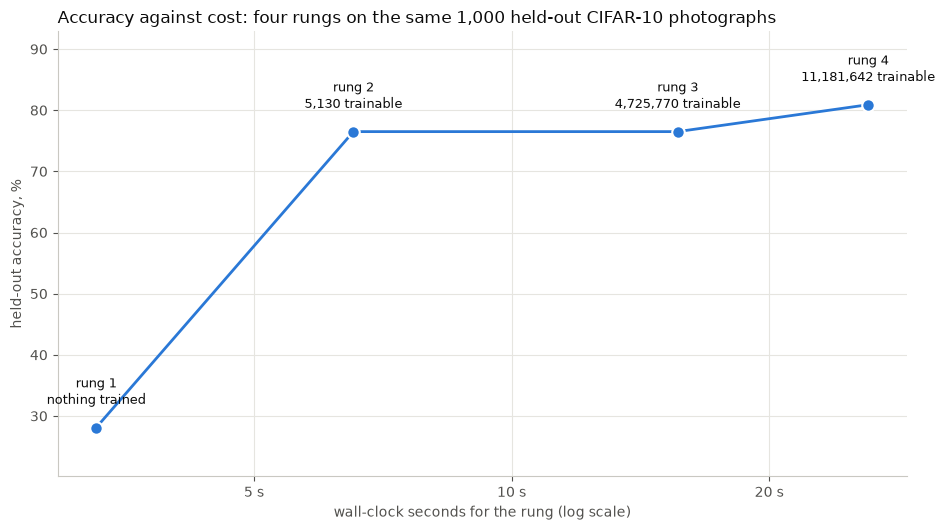

In [7]:
import matplotlib.pyplot as plt

total_params = n_params(full)
print(f"{'rung':<58}{'trainable':>12}{'% of model':>12}{'seconds':>9}{'accuracy':>10}{'sec per +1 point':>26}")
print("-" * 127)
for k, row in enumerate(LADDER):
    if k == 0:
        price = "(baseline)"
    else:
        d_acc = (row["accuracy"] - LADDER[k - 1]["accuracy"]) * 100
        d_sec = row["seconds"] - LADDER[k - 1]["seconds"]
        price = f"{d_sec / d_acc:.1f}" if d_acc > 0 else f"no gain ({d_acc:+.1f} points)"
    print(f"{row['rung']:<58}{row['trainable']:>12,}{row['trainable'] / total_params:>11.1%}"
          f"{row['seconds']:>9.1f}{row['accuracy']:>10.1%}{price:>26}")
print("-" * 127)
print(f"all four rungs together: {sum(r['seconds'] for r in LADDER):.1f} s on {DEVICE}")

# One series, so no legend: the title names it. Text stays in ink colours; only the marks carry the series colour.
INK, INK_2, SERIES = "#0b0b0b", "#52514e", "#2a78d6"
secs = [r["seconds"] for r in LADDER]
accs = [r["accuracy"] * 100 for r in LADDER]
fig, ax = plt.subplots(figsize=(9.6, 5.4))
ax.plot(secs, accs, color=SERIES, linewidth=2, marker="o", markersize=9, markeredgecolor="white", markeredgewidth=1.5,
        zorder=3)
for k, r in enumerate(LADDER):
    label = f"rung {k + 1}\n{r['trainable']:,} trainable" if r["trainable"] else f"rung {k + 1}\nnothing trained"
    ax.annotate(label, (secs[k], accs[k]), xytext=(0, 14), textcoords="offset points", ha="center", va="bottom",
                fontsize=9, color=INK)
ax.set_xscale("log")
ticks = [t for t in (1, 2, 5, 10, 20, 50, 100, 200) if min(secs) / 1.5 <= t <= max(secs) * 1.5]
ax.set_xticks(ticks, [f"{t} s" for t in ticks])     # plain seconds instead of matplotlib's 10^n labels
ax.set_xticks([], minor=True)
ax.set_xlabel("wall-clock seconds for the rung (log scale)", color=INK_2)
ax.set_ylabel("held-out accuracy, %", color=INK_2)
ax.set_title("Accuracy against cost: four rungs on the same 1,000 held-out CIFAR-10 photographs", color=INK,
             fontsize=12, loc="left")
lo, hi = min(accs), max(accs)
ax.set_ylim(lo - 8, hi + 12)
ax.grid(True, color="#e6e5e0", linewidth=0.8, zorder=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#c9c8c2")
ax.tick_params(colors=INK_2)
plt.tight_layout()
plt.show()

**📊 Read the table.** Four rungs, the same 1,000 held-out photographs. In the run recorded in this notebook:

- **Rung 1 → rung 2 is the whole story of transfer learning.** Accuracy went from 28.1% to 76.5% for 5,130 trainable weights and about three extra seconds, almost all of them spent computing the 512 features once for 2,000 images. Rung 1 was cheap and bad for a reason the per-class line shows: the model does not speak our labels. 55% of its answers had no CIFAR-10 meaning at all, and "cat" scored 5% because only five of the 1,000 ImageNet classes were given the meaning "cat" and the model rarely chose one of them. Rung 2 learned the ten labels from 1,000 examples, and the same frozen features that scored 28.1% through a hand-written table scored 76.5% through a learned 512→10 layer.
- **Rung 2 → rung 3 bought nothing.** 4.7 million weights moved (42% of the model), the rung took 2.4× as long, and held-out accuracy stayed at 76.5%. Look at the per-class line, though: the number is the same, the model is not. Bird went from 59% to 72% and dog from 73% to 85%, while cat fell from 64% to 45%. Three epochs over 100 examples per class is enough to move a block, and not enough to move it in a direction that helps everywhere.
- **Rung 3 → rung 4 bought 4.4 points for 10.5 more seconds**, about 2.4 s per point in this run. Letting every layer move helped the classes the frozen features handled worst (cat back to 65%, truck to 95%). It was the most accurate rung here, and it was also the one with 11.2 million weights free to drift, which is the risk "Where this breaks" names.
- **The shape of the figure** is the shape to expect in general, even when your numbers differ: a cliff between "no labels" and "a learned head", then a slope that gets flatter as the cost axis gets longer. Where you stop climbing depends on what one point of accuracy is worth to you, and that is a question about the job, not about the model.

Two warnings before you quote any of this. The seconds column belongs to this machine (the first cell printed the device); on a GPU the whole column shrinks and the ratios change. And with 1,000 held-out images the standard error of an accuracy near 77% is about 1.3 points (√(0.77 × 0.23 / 1000)), so a difference of a point or two between rungs is inside sampling noise. The 48-point cliff is not; the 4.4-point step is worth a second run before you rely on it.

## 🔭 State of the field (2026)

The middle rung has a 2026 form. For language models there is a version of rung 3 that does not unfreeze a block at all: a **low-rank update** (LoRA; Hu et al., 2021) trains a small pair of matrices *next to* each frozen weight, and the frozen weight never changes. Course 03 Unit 1, `enrichment/E5_lora_on_a_matrix.ipynb`, does that arithmetic on one matrix. The ladder is the same: rung 3 touches a fraction of the weights, and the question stays where it was: where does accuracy stop paying for cost?

The four rungs also map onto what you will meet with a language model in Course 10. Rung 1 is prompting an API. Rung 2 is an embedding model with a small classifier on top. Rung 3 is a LoRA adapter. Rung 4 is what the model's owner did, and it is the rung this lesson has just shown you to climb last.

## 🧩 Try it

Each of these is a one-line change in the first cell, then *Run All*. Write down the table before and after.

1. **`N_PER_CLASS_TRAIN = 20`** (200 training images instead of 1,000). Which rung wins now, and did the order of rungs 3 and 4 change?
2. **`EPOCHS = 10`**. Does rung 4 pass rung 3? Read the seconds column before you answer whether it was worth it.
3. **Widen the rung-1 table**: add the big cats (`286` to `293`, cougar through cheetah) to `"cat"`. Accuracy went where? Now say, in one sentence, what kind of object you just improved. Lesson 01 has the word for it.
4. **Delete the `model.eval()` line in `train()`** and re-run. Rung 2 is untouched (its backbone never trains). Rungs 3 and 4 change; write down by how much, then explain it using only the comment you deleted. This is the most common silent bug in fine-tuning code, and it does not raise an error.

## 💬 Discuss

1. A client has 1,000 labelled photographs of damaged car parts, no GPU, and a deadline on Friday. Using the table you just printed, pick a rung and defend it to two people at once: the engineer who says "always fine-tune, it is more accurate" and the manager who says "just use the pretrained model, it is free". Neither of them is entirely wrong.
2. Rung 1 needed no labels and no training, but it needed a person to write the ImageNet-to-CIFAR table by hand, and for "deer" the table is a guess. Rung 2 needed 1,000 labels. Which of those two costs is larger in a real company, and who pays it?
3. Rung 4 is the most expensive rung and it also has the most ways to go wrong (the next section names one). If your team could only afford to *monitor* one rung in production, which one would you pick, and what single number would you watch?

## ⚠️ Where this breaks

- **The label space, measured above.** ImageNet has no deer, so rung 1 can never say "deer"; the mapping sends antelopes there instead, and the per-class line printed under rung 1 shows what that costs. Rung 1 is free only when the pretrained model already speaks your labels. When it does not, the "free" rung includes a person writing rules, and you are back at the problem lesson 01 opened with.
- **The top of the ladder is not the safe end.** Kumar, Raghunathan, Jones, Ma and Liang (ICLR 2022) measured full fine-tuning against a frozen backbone across ten distribution shifts: fine-tuning "obtains on average 2% higher accuracy ID but 7% lower accuracy OOD than linear probing". Every weight that moves can move away from what made the features general. Our held-out images come from the same collection as the training ones, so this notebook cannot show that failure; it happens when the photographs in production differ from the ones you fine-tuned on, which is the normal case.
- **When the domain is far, the whole ladder may be the wrong tool.** Raghu, Zhang, Kleinberg and Bengio (NeurIPS 2019) evaluated ImageNet transfer on two large medical-imaging tasks and reported that "transfer offers little benefit to performance, and simple, lightweight models can perform comparably to ImageNet architectures". Course 08 Unit 2, lesson 05, sees the same direction on MNIST. Look at your images next to ImageNet photographs before you climb a single rung.
- **What the numbers here are, and are not.** 32-px photographs upscaled to 96 px, 1,000 training images, three epochs, a laptop CPU. The accuracies are for comparing rungs, not for quoting as what ResNet-18 can do on CIFAR-10. The seconds are for *this* machine; on a GPU the whole column shrinks and the ratios change, so re-run the table on the hardware you will actually use before you decide.
- **Wall-clock is a noisy instrument.** Another process, a hot laptop on battery, or a first-time download will move every number in the seconds column. Run twice before you believe a difference of a few seconds.

## ✅ Summary

- Four ways to use a pretrained model are one ladder: **as-is, frozen + head, partial fine-tune, full fine-tune**, in ascending cost.
- The three numbers to print for each rung are **trainable parameters, wall-clock seconds and held-out accuracy**, on the same data.
- The decision is read off the table: climb until the next rung stops paying for its cost, and stop there.
- Two things the ladder cannot fix: a pretrained model that does not speak your labels, and a domain far from the one it was trained on.

## 📚 References

- Krizhevsky, A. (2009). *Learning Multiple Layers of Features from Tiny Images.* Technical report, University of Toronto. The CIFAR-10 dataset: https://cave.cs.toronto.edu/kriz/cifar.html
- Yosinski, J., Clune, J., Bengio, Y. & Lipson, H. (2014). *How transferable are features in deep neural networks?* NeurIPS 27. https://arxiv.org/abs/1411.1792 (why rung 3 unfreezes the *last* block)
- Kumar, A., Raghunathan, A., Jones, R., Ma, T. & Liang, P. (2022). *Fine-Tuning can Distort Pretrained Features and Underperform Out-of-Distribution.* ICLR. https://arxiv.org/abs/2202.10054 (why rungs 3 and 4 start from the trained head; the out-of-distribution warning)
- Raghu, M., Zhang, C., Kleinberg, J. & Bengio, S. (2019). *Transfusion: Understanding Transfer Learning for Medical Imaging.* NeurIPS. https://arxiv.org/abs/1902.07208 (when the domain is far)
- Hu, E. J. et al. (2021). *LoRA: Low-Rank Adaptation of Large Language Models.* https://arxiv.org/abs/2106.09685 (the 2026 form of rung 3; worked through in Course 03 U1, E5)